# Henry Hub Natural Gas Price Forecasting

Monthly forecast of `Natural_Gas_US_Henry_Hub_Gas` at 1/2/3-month horizons, walk-forward over the 2020-09 to 2024-08 test window.

Structure:
1. Data load, cleaning, exploratory analysis
2. Naive (random-walk) baseline
3. Feature engineering + regularized models (LightGBM, Ridge, Lasso), tuned on a 2017-2020 validation slice
4. Expanding-window backtest over the test period, final `submission.csv`
5. Feature attribution (SHAP) and inflection-point analysis around the 2021 freeze and 2022 supply shock

In [1]:
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import shap
from sklearn.linear_model import LassoCV, RidgeCV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
pd.set_option("display.max_columns", 50)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# ---------------------------------------------------------------------------
# Config: every tunable constant lives here, nowhere else in the notebook.
# ---------------------------------------------------------------------------
DATA_DIR = Path(".")
TRAIN_PATH = DATA_DIR / "★data_train.csv"
TEST_PATH = DATA_DIR / "★data_test.csv"
METADATA_PATH = DATA_DIR / "★metadata.xlsx"
SUBMISSION_EXAMPLE_PATH = DATA_DIR / "★submission_example.csv"
SUBMISSION_OUT_PATH = DATA_DIR / "submission.csv"

DATE_COL = "date"
TARGET = "Natural_Gas_US_Henry_Hub_Gas"
HORIZONS = [1, 2, 3]

# Columns that are 100% missing in train -> useless, dropped on load.
ALWAYS_MISSING_COLS = ["Services_PMI", "Construction_PMI"]

# Feature-engineering knobs (used from Step 3 onward).
TARGET_LAGS = [1, 2, 3, 6, 12]
STORAGE_COLS_FOR_DELTA = [
    "Total_Natural_Gas_Underground_Storage_Volume_USA",
    "EU_Aggregated_Gas_Storage_Inventory",
]
# Above this missing fraction (computed on train), a raw feature is dropped
# rather than imputed -- too little signal left to trust an imputed value.
MAX_MISSING_FRACTION = 0.40

# Walk-forward validation window used for model selection / Optuna tuning.
# Kept strictly inside train so the test period is never touched until Step 4.
VALIDATION_START = "2017-01-31"
VALIDATION_END = "2020-08-31"

N_OPTUNA_TRIALS = 30
RANDOM_SEED = 42

EVENTS = {
    "2008-09-15": "2008 financial crisis",
    "2020-04-30": "2020 COVID demand collapse",
    "2021-02-28": "Feb 2021 Texas freeze (Winter Storm Uri)",
    "2022-02-24": "2022 Russia invades Ukraine",
}

## Step 1 — Load, clean, explore

`data_test.csv` isn't blind future data: it holds the actual 2020-09→2024-08 history, including the real Henry Hub price. That's what makes an honest backtest possible later, but it also means this exploration can safely look across the full timeline when it's just describing what happened, while feature/label construction for modeling stays strictly walk-forward (Step 3 onward).

In [2]:
def load_data(path: Path) -> pd.DataFrame:
    """Read one of the provided CSVs, parse dates, drop the always-empty columns."""
    df = pd.read_csv(path)
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    df = df.drop(columns=[c for c in ALWAYS_MISSING_COLS if c in df.columns])
    return df.sort_values(DATE_COL).reset_index(drop=True)


train_df = load_data(TRAIN_PATH)
test_df = load_data(TEST_PATH)
metadata_df = pd.read_excel(METADATA_PATH)

print(f"train: {train_df.shape}, {train_df[DATE_COL].min().date()} -> {train_df[DATE_COL].max().date()}")
print(f"test:  {test_df.shape}, {test_df[DATE_COL].min().date()} -> {test_df[DATE_COL].max().date()}")
print(f"dropped always-missing columns: {ALWAYS_MISSING_COLS}")
print(f"metadata rows: {len(metadata_df)}")
metadata_df.head()

train: (204, 112), 2003-09-30 -> 2020-08-31
test:  (48, 112), 2020-09-30 -> 2024-08-31
dropped always-missing columns: ['Services_PMI', 'Construction_PMI']
metadata rows: 113


,name,unit,description,Korean description
0,Brent_Crude_Oil_Daily,Dollar per Barrel($/BBL),Europe Brent Spot Price FOB (Dollars per Barrel),유럽 브렌트 현물 가격 FOB (배럴당 달러)
1,WTI_Crude_Oil_Daily,Dollar per Barrel($/BBL),"Cushing, OK WTI Spot Price FOB (Dollars per Ba...",오클라호마 커싱 WTI 현물 가격 FOB (배럴당 달러)
2,Electricity_Price_USA,cents per kilowatthour,Electricity Sales To Ultimate Customers Average,최종 소비자에 대한 평균 전력 판매량
3,Heating_Oil_Price_USA,Dollars per Gallon($/GAL),U.S. No. 2 Heating Oil Residential Price (Doll...,미국 제2 주택용 난방유 가격 (갤런당 달러)
4,Natural_Gas_Imports_From_Canada_USA,Million Cubic Feat(MMCF),U.S. Natural Gas Pipeline Imports From Canada ...,미국 천연가스 캐나다로부터의 파이프라인 수입 (MMcf)


### Missing values

Missingness is computed on train, since that's what any imputation decision has to be based on. Anything above `MAX_MISSING_FRACTION` (40%) will be dropped rather than imputed in Step 3 — with 204 rows, filling in more than 40% of a column's history manufactures more signal than the data actually has.

33 of 111 columns have some missing values in train
6 columns exceed the 40% drop threshold:
  Comprehensive_PMI                                                      78.4%
  M_PMI_Comp_Producer_Prices                                             73.0%
  M_PMI_Comp_Expected_Production_and_Business_Activities                 54.9%
  Heating_Oil_Price_USA                                                  50.0%
  EU_Aggregated_LNG_System_Inventory                                     49.0%
  EU_Aggregated_Gas_Storage_Inventory                                    43.1%


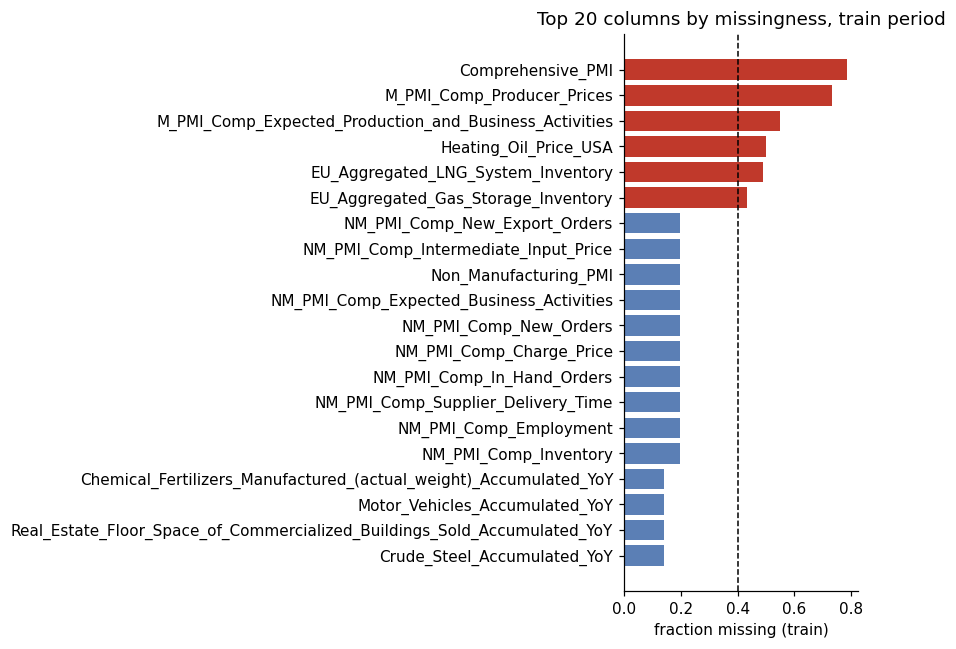

In [3]:
missing_frac = train_df.drop(columns=[DATE_COL]).isna().mean().sort_values(ascending=False)
missing_frac = missing_frac[missing_frac > 0]
high_missing_cols = missing_frac[missing_frac > MAX_MISSING_FRACTION].index.tolist()

print(f"{len(missing_frac)} of {train_df.shape[1] - 1} columns have some missing values in train")
print(f"{len(high_missing_cols)} columns exceed the {MAX_MISSING_FRACTION:.0%} drop threshold:")
for c in high_missing_cols:
    print(f"  {c:<70s} {missing_frac[c]:.1%}")

fig, ax = plt.subplots(figsize=(8, 6))
top20 = missing_frac.head(20).iloc[::-1]
colors = ["#c0392b" if v > MAX_MISSING_FRACTION else "#5b7fb5" for v in top20.values]
ax.barh(top20.index, top20.values, color=colors)
ax.axvline(MAX_MISSING_FRACTION, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("fraction missing (train)")
ax.set_title("Top 20 columns by missingness, train period")
plt.tight_layout()
plt.show()

### Target over time

Full known history (train + test), since this is a descriptive plot of what actually happened, not a model input.

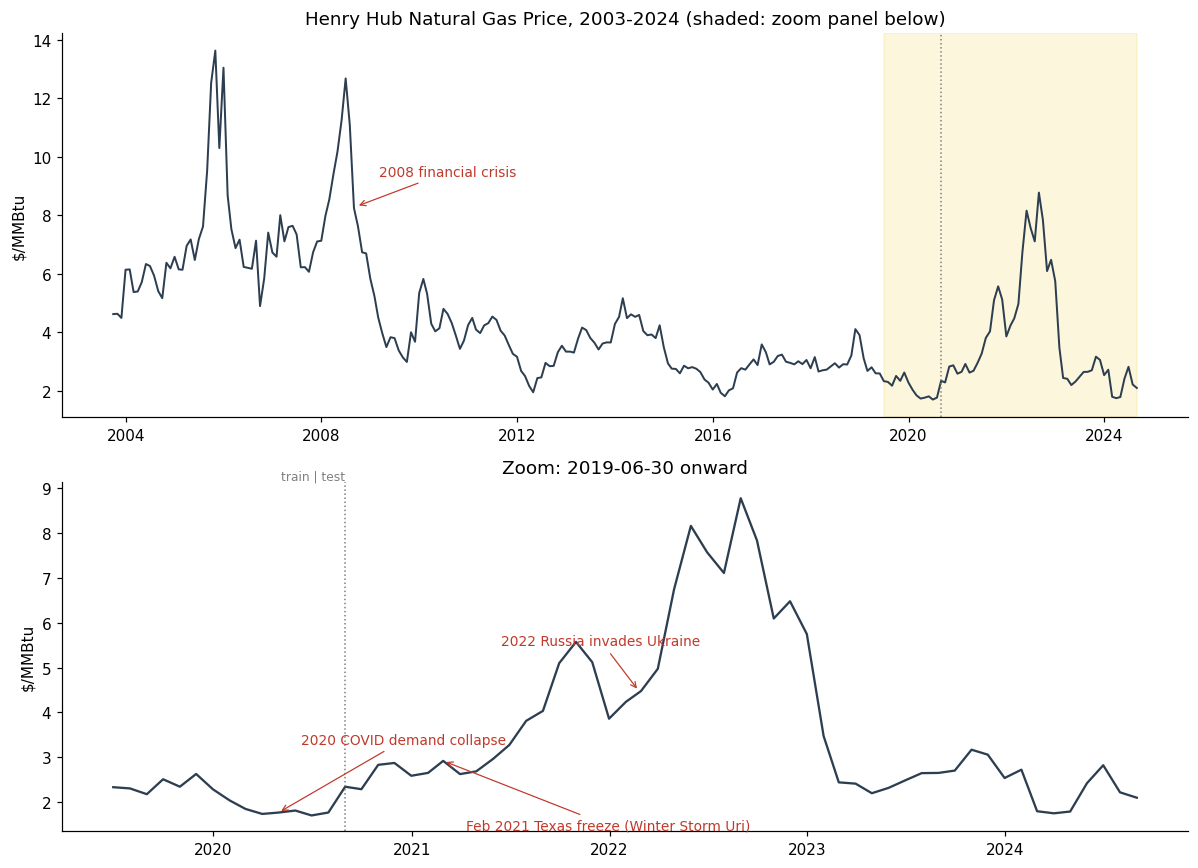

In [4]:
full_history = pd.concat([train_df, test_df], ignore_index=True).sort_values(DATE_COL)
recent_start = pd.Timestamp("2019-06-30")

fig, (ax_full, ax_recent) = plt.subplots(2, 1, figsize=(11, 8), height_ratios=[1.1, 1])

ax_full.plot(full_history[DATE_COL], full_history[TARGET], color="#2c3e50", linewidth=1.3)
ax_full.axvline(train_df[DATE_COL].max(), color="grey", linestyle=":", linewidth=1)
ax_full.axvspan(recent_start, full_history[DATE_COL].max(), color="#f0c419", alpha=0.15)
ax_full.annotate(
    "2008 financial crisis",
    xy=(pd.Timestamp("2008-09-15"), 8.3),
    xytext=(15, 20),
    textcoords="offset points",
    fontsize=9,
    color="#c0392b",
    arrowprops=dict(arrowstyle="->", color="#c0392b", lw=0.8),
)
ax_full.set_ylabel("$/MMBtu")
ax_full.set_title("Henry Hub Natural Gas Price, 2003-2024 (shaded: zoom panel below)")

recent = full_history[full_history[DATE_COL] >= recent_start]
ax_recent.plot(recent[DATE_COL], recent[TARGET], color="#2c3e50", linewidth=1.5)
ax_recent.axvline(train_df[DATE_COL].max(), color="grey", linestyle=":", linewidth=1)
ax_recent.text(train_df[DATE_COL].max(), ax_recent.get_ylim()[1], "train | test",
               ha="right", va="bottom", fontsize=8, color="grey")

recent_events = {k: v for k, v in EVENTS.items() if pd.Timestamp(k) >= recent_start}
offsets = [(15, 45), (15, -45), (-90, 30)]
for (date_str, label), offset in zip(recent_events.items(), offsets):
    d = pd.Timestamp(date_str)
    y = recent.loc[(recent[DATE_COL] - d).abs().idxmin(), TARGET]
    ax_recent.annotate(
        label,
        xy=(d, y),
        xytext=offset,
        textcoords="offset points",
        fontsize=9,
        color="#c0392b",
        arrowprops=dict(arrowstyle="->", color="#c0392b", lw=0.8),
    )
ax_recent.set_ylabel("$/MMBtu")
ax_recent.set_title(f"Zoom: {recent_start.date()} onward")

plt.tight_layout()
plt.show()

### Correlation with key feature groups

Computed on train only (this is the data any model selection has to be based on). Grouped by the categories called out in the brief: storage, temperature, rig count, oil prices, and the dollar index.

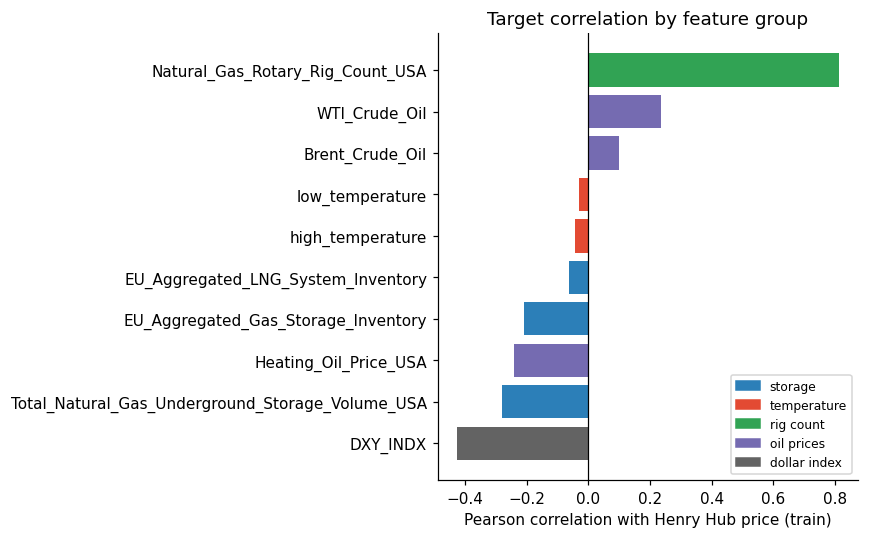

,group,feature,corr_with_target
9,dollar index,DXY_INDX,-0.426
0,storage,Total_Natural_Gas_Underground_Storage_Volume_USA,-0.279
8,oil prices,Heating_Oil_Price_USA,-0.241
1,storage,EU_Aggregated_Gas_Storage_Inventory,-0.208
2,storage,EU_Aggregated_LNG_System_Inventory,-0.062
3,temperature,high_temperature,-0.043
4,temperature,low_temperature,-0.031
6,oil prices,Brent_Crude_Oil,0.098
7,oil prices,WTI_Crude_Oil,0.236
5,rig count,Natural_Gas_Rotary_Rig_Count_USA,0.813


In [5]:
FEATURE_GROUPS = {
    "storage": [
        "Total_Natural_Gas_Underground_Storage_Volume_USA",
        "EU_Aggregated_Gas_Storage_Inventory",
        "EU_Aggregated_LNG_System_Inventory",
    ],
    "temperature": ["high_temperature", "low_temperature"],
    "rig count": ["Natural_Gas_Rotary_Rig_Count_USA"],
    "oil prices": ["Brent_Crude_Oil", "WTI_Crude_Oil", "Heating_Oil_Price_USA"],
    "dollar index": ["DXY_INDX"],
}

corr_rows = []
for group, cols in FEATURE_GROUPS.items():
    for c in cols:
        if c in train_df.columns:
            corr_rows.append((group, c, train_df[c].corr(train_df[TARGET])))
corr_df = pd.DataFrame(corr_rows, columns=["group", "feature", "corr_with_target"])
corr_df = corr_df.sort_values("corr_with_target")

fig, ax = plt.subplots(figsize=(8, 5))
group_colors = {"storage": "#2c7fb8", "temperature": "#e34a33", "rig count": "#31a354",
                 "oil prices": "#756bb1", "dollar index": "#636363"}
colors = corr_df["group"].map(group_colors)
ax.barh(corr_df["feature"], corr_df["corr_with_target"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson correlation with Henry Hub price (train)")
ax.set_title("Target correlation by feature group")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in group_colors.values()]
ax.legend(handles, group_colors.keys(), loc="lower right", fontsize=8)
plt.tight_layout()
plt.show()

corr_df.round(3)

**Step 1 takeaways**

- History is dominated by four regimes: the 2005-2008 run-up, the 2008-2009 crash, a long 2012-2019 range around $2-4, and the 2021-2022 spike (Texas freeze into the Ukraine-driven European gas crisis) that unwound through 2023.
- `DXY_INDX` correlates negatively with price (-0.43), consistent with the dollar-index relationship flagged in the brief.
- `Natural_Gas_Rotary_Rig_Count_USA` correlates positively and strongly (+0.81) with contemporaneous price, but rig count reacts to price with a lag (drilling economics), so at same-month `t` it's not a leading indicator — worth lagging if used as a feature.
- Storage and temperature show the expected sign (more storage / milder temperature → softer prices) but the relationship is weak in raw monthly levels; deltas and heating-degree framing are likely to carry more signal than levels, which motivates the storage-delta features in Step 3.
- Six columns exceed the 40% missing threshold and will be dropped rather than imputed in Step 3.

## Step 2 — Naive baseline

The baseline is a random walk: whatever the price is at date `t`, assume it stays there for `t+1`, `t+2`, `t+3`. It costs nothing to compute and, for a commodity this close to a random walk month-to-month, is a genuinely hard number to beat — which is exactly why it belongs first. The evaluation harness built here (`mape`, `add_horizon_targets`, `walk_forward_predict`, `score_walk_forward`) is the same one Step 3 reuses for the real models, so the comparison is apples-to-apples.

In [6]:
def mape(actual, pred) -> float:
    """Mean absolute percentage error, in percent."""
    actual = np.asarray(actual, dtype=float)
    pred = np.asarray(pred, dtype=float)
    return float(np.mean(np.abs((actual - pred) / actual)) * 100)


def add_horizon_targets(df: pd.DataFrame, target_col: str, horizons: list[int]) -> pd.DataFrame:
    """Attach target_h{h} = target_col shifted h months into the future, aligned by row order.

    Relies on the panel being a contiguous, sorted, monthly series (checked below), so a
    plain `.shift(-h)` is equivalent to looking up the value h calendar months ahead.
    """
    out = df.sort_values(DATE_COL).reset_index(drop=True)
    for h in horizons:
        out[f"target_h{h}"] = out[target_col].shift(-h)
    return out


def walk_forward_predict(df: pd.DataFrame, predict_fn, val_dates, horizons: list[int]) -> pd.DataFrame:
    """Call predict_fn(history, t) at every date in val_dates, where history = df[df.date <= t].

    predict_fn must return {h: prediction}. Because history is truncated at t before predict_fn
    ever sees it, no predict_fn implementation can peek past t -- this is what makes the harness
    walk-forward safe regardless of what predict_fn does internally (naive lookup or full refit).
    """
    rows = []
    for t in val_dates:
        history = df.loc[df[DATE_COL] <= t]
        preds = predict_fn(history, t)
        for h in horizons:
            rows.append({DATE_COL: t, "horizon": h, "pred": preds[h]})
    return pd.DataFrame(rows)


def score_walk_forward(pred_long: pd.DataFrame, truth_df: pd.DataFrame, horizons: list[int]) -> dict[int, float]:
    """Merge walk-forward predictions with realized target_h{h} values and compute MAPE per horizon.

    Rows where the realized value falls outside the provided data (tail of the window) are
    dropped rather than treated as zero error.
    """
    truth_cols = [DATE_COL] + [f"target_h{h}" for h in horizons]
    merged = pred_long.merge(truth_df[truth_cols], on=DATE_COL, how="left")
    result = {}
    for h in horizons:
        sub = merged.loc[merged["horizon"] == h, ["pred", f"target_h{h}"]].dropna()
        result[h] = mape(sub[f"target_h{h}"], sub["pred"])
    return result


# Sanity check: the panel must be gap-free monthly data for the shift-based lookup above to be valid.
_gaps = full_history[DATE_COL].diff().dt.days.dropna()
assert _gaps.between(27, 32).all(), "expected a contiguous monthly panel with no gaps"

results_records: list[dict] = []


def record_result(model_name: str, mape_by_horizon: dict[int, float]) -> None:
    for h, v in mape_by_horizon.items():
        results_records.append({"model": model_name, "horizon": h, "mape": v})

In [7]:
def naive_predict(history: pd.DataFrame, t: pd.Timestamp, horizons: list[int] = HORIZONS) -> dict:
    """Random-walk baseline: carry the last known value forward for every horizon."""
    last_value = history.loc[history[DATE_COL] == t, TARGET].iloc[0]
    return {h: last_value for h in horizons}


val_dates = train_df.loc[
    (train_df[DATE_COL] >= VALIDATION_START) & (train_df[DATE_COL] <= VALIDATION_END), DATE_COL
].tolist()
print(f"validation window: {val_dates[0].date()} -> {val_dates[-1].date()} ({len(val_dates)} months)")

train_truth = add_horizon_targets(train_df, TARGET, HORIZONS)
naive_preds = walk_forward_predict(train_df, naive_predict, val_dates, HORIZONS)
naive_mape = score_walk_forward(naive_preds, train_truth, HORIZONS)
record_result("naive (random walk)", naive_mape)

for h in HORIZONS:
    print(f"  h={h}: MAPE = {naive_mape[h]:.2f}%")

validation window: 2017-01-31 -> 2020-08-31 (44 months)
  h=1: MAPE = 7.71%
  h=2: MAPE = 10.07%
  h=3: MAPE = 12.61%


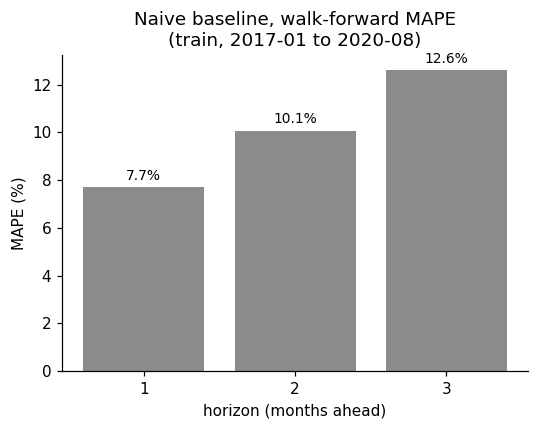

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([str(h) for h in HORIZONS], [naive_mape[h] for h in HORIZONS], color="#8c8c8c")
for h in HORIZONS:
    ax.text(h - 1, naive_mape[h] + 0.3, f"{naive_mape[h]:.1f}%", ha="center", fontsize=9)
ax.set_xlabel("horizon (months ahead)")
ax.set_ylabel("MAPE (%)")
ax.set_title("Naive baseline, walk-forward MAPE\n(train, 2017-01 to 2020-08)")
plt.tight_layout()
plt.show()

## Step 3 — Feature engineering + regularized models

### Feature set

Deliberately three families only: target lags, calendar seasonality, and the US storage delta. Step 1 showed temperature, oil, DXY, and rig count are either weak in raw monthly levels or contemporaneous rather than predictive, and EU storage fails the same missingness bar applied to every other column — so none of them earn a place in an 8-feature model built on 204 rows. A side benefit: both target and US storage are 100%-populated in train, so this feature set needs no imputation at all.

In [9]:
US_STORAGE_COL = "Total_Natural_Gas_Underground_Storage_Volume_USA"
FEATURE_COLS = [f"lag_{lag}" for lag in TARGET_LAGS] + ["month_sin", "month_cos", "us_storage_delta"]


def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """Raw monthly panel -> model-ready feature frame.

    Every feature at row t is a function of information available at or before t:
    lag_k is the target k months earlier, the seasonal terms are calendar facts about t
    itself, and us_storage_delta is storage(t) - storage(t-1). See the assertion cell
    right below for a mechanical check of this claim.
    """
    raw = df.sort_values(DATE_COL).reset_index(drop=True)
    out = raw[[DATE_COL, TARGET]].copy()

    for lag in TARGET_LAGS:
        out[f"lag_{lag}"] = raw[TARGET].shift(lag)

    out["month_sin"] = np.sin(2 * np.pi * raw[DATE_COL].dt.month / 12)
    out["month_cos"] = np.cos(2 * np.pi * raw[DATE_COL].dt.month / 12)
    out["us_storage_delta"] = raw[US_STORAGE_COL].diff(1)

    return out


sample_features = build_features(train_df)
sample_features.tail()

,date,Natural_Gas_US_Henry_Hub_Gas,lag_1,lag_2,lag_3,lag_6,lag_12,month_sin,month_cos,us_storage_delta
199,2020-04-30,1.76364,1.73318,1.84500,2.03391,2.34087,2.59727,8.660254e-01,-0.500000,307780.0
200,2020-05-31,1.80905,1.76364,1.73318,1.84500,2.62524,2.59174,5.000000e-01,-0.866025,447780.0
201,2020-06-30,1.69955,1.80905,1.76364,1.73318,2.28273,2.33000,1.224647e-16,-1.000000,358290.0
202,2020-07-31,1.76478,1.69955,1.80905,1.76364,2.03391,2.30217,-5.000000e-01,-0.866025,161290.0
203,2020-08-31,2.34048,1.76478,1.69955,1.80905,1.84500,2.17364,-8.660254e-01,-0.500000,228110.0


### Leakage assertion

Two independent checks: the lag/delta arithmetic actually matches a plain shift (not an off-by-one, not a centered window), and — more importantly — feature values computed from `history_up_to_t` are identical to feature values computed from the full panel at the same date `t`. The second check is the real proof that walk-forward truncation works: if any feature secretly depended on rows after `t`, cutting the panel at `t` would change its value, and it doesn't.

In [10]:
def assert_no_lookahead(df: pd.DataFrame) -> None:
    """Mechanically verify build_features() never encodes information from after date t."""
    raw = df.sort_values(DATE_COL).reset_index(drop=True).set_index(DATE_COL)
    feats = build_features(df).set_index(DATE_COL)

    for lag in TARGET_LAGS:
        expected = raw[TARGET].shift(lag)
        diff = (expected - feats[f"lag_{lag}"]).abs()
        bad = diff[diff.notna() & (diff > 1e-9)]
        assert bad.empty, f"lag_{lag} does not equal target shifted {lag} months at: {bad.index.tolist()}"

    expected_delta = raw[US_STORAGE_COL].diff(1)
    diff = (expected_delta - feats["us_storage_delta"]).abs()
    bad = diff[diff.notna() & (diff > 1e-9)]
    assert bad.empty, f"us_storage_delta does not equal a 1-month difference at: {bad.index.tolist()}"


def assert_truncation_invariant(df: pd.DataFrame, check_dates: list[pd.Timestamp]) -> None:
    """Feature values at t must be identical whether built from history<=t or from the full panel."""
    full_feats = build_features(df).set_index(DATE_COL)
    for t in check_dates:
        history = df.loc[df[DATE_COL] <= t]
        truncated_row = build_features(history).set_index(DATE_COL).loc[t, FEATURE_COLS]
        full_row = full_feats.loc[t, FEATURE_COLS]
        assert np.allclose(truncated_row.values, full_row.values, equal_nan=True), (
            f"feature values at {t.date()} depend on data after t"
        )


assert_no_lookahead(train_df)
assert_no_lookahead(pd.concat([train_df, test_df], ignore_index=True))

check_dates = pd.to_datetime(["2010-06-30", "2015-06-30", "2020-08-31"])
check_dates = list(check_dates) + val_dates[::10]
assert_truncation_invariant(train_df, check_dates)

print("leakage checks passed:")
print(f"  - lag_k at date t equals raw target at t-k, for k in {TARGET_LAGS}")
print("  - us_storage_delta at date t equals storage(t) - storage(t-1)")
print(f"  - feature values at t are unchanged when history is truncated to <= t, checked at {len(check_dates)} dates")

leakage checks passed:
  - lag_k at date t equals raw target at t-k, for k in [1, 2, 3, 6, 12]
  - us_storage_delta at date t equals storage(t) - storage(t-1)
  - feature values at t are unchanged when history is truncated to <= t, checked at 8 dates


### Models

Direct strategy: one model per horizon, each trained to predict horizon `h` straight from the features at `t` (no iterating h=1 forecasts forward into h=2 inputs, which would compound errors).

Henry Hub is close to a random walk, which makes the naive baseline a genuinely hard target — the first attempt below, fitting Ridge/Lasso directly against the *level* of the price, actually loses to it. The diagnostic cell shows why, and the fix (predicting the *change* in price rather than its level) is what the rest of Step 3 uses for every model, including LightGBM.

In [11]:
RIDGE_ALPHAS = np.logspace(-2, 3, 30)
LASSO_ALPHAS = np.logspace(-3, 1, 30)
LINEAR_CV = TimeSeriesSplit(n_splits=5)  # time-respecting folds, not the default shuffled/LOO CV

# Diagnostic: fit Ridge directly on the price *level* near the end of the validation window,
# and look at what it actually learned.
diag_history = train_df.loc[train_df[DATE_COL] <= "2020-06-30"]
diag_feats = add_horizon_targets(build_features(diag_history), TARGET, HORIZONS)
diag_rows = diag_feats.dropna(subset=FEATURE_COLS + ["target_h1"])

diag_pipe = Pipeline([("scale", StandardScaler()), ("model", RidgeCV(alphas=RIDGE_ALPHAS, cv=LINEAR_CV))])
diag_pipe.fit(diag_rows[FEATURE_COLS], diag_rows["target_h1"])
print(f"n training rows: {len(diag_rows)}")
print(f"RidgeCV selected alpha: {diag_pipe.named_steps['model'].alpha_:.4f}  (grid min: {RIDGE_ALPHAS.min():.4f})")
for name, coef in zip(FEATURE_COLS, diag_pipe.named_steps["model"].coef_):
    print(f"  {name:<18s} {coef: .4f}")

n training rows: 189
RidgeCV selected alpha: 0.0100  (grid min: 0.0100)
  lag_1               2.3310
  lag_2               0.0868
  lag_3              -0.4100
  lag_6              -0.0212
  lag_12              0.1922
  month_sin          -0.0774
  month_cos          -0.0779
  us_storage_delta   -0.0493


`RidgeCV` picks the weakest alpha on the grid and still ends up with `lag_1 = 2.33`, `lag_3 = -0.41` — the five lag features are highly collinear, so even light regularization lets the model split "one month ago" credit across several correlated lags in a way that cancels out badly on new data, instead of settling near the stable `lag_1 ≈ 1, rest ≈ 0` solution a random walk implies. That is also why it loses to the naive baseline: it isn't underfit, it's finding in-sample structure among the lags that doesn't hold up walk-forward.

Fix: reframe every model to predict `delta_h = price(t+h) - price(t)` instead of the level, then add `price(t)` back afterward. Two consequences, both wanted: (1) a model that shrinks all coefficients to zero now reproduces the naive baseline exactly rather than something worse, so regularization can only help; (2) tree models (LightGBM, next) stop being capped at the highest price level seen in training, since the reconstructed prediction is anchored to the *current* price, not to a leaf value memorized from training years — which matters directly for forecasting into the 2021-2022 spike from a model trained on pre-2020 data.

In [12]:
def make_model_predict_fn(model_factory: dict[int, "callable"]):
    """Turn {horizon: zero-arg estimator factory} into a walk_forward_predict-compatible predict_fn.

    Models are fit against delta_h = price(t+h) - price(t), not the raw level (see the
    diagnostic above), then the prediction is reconstructed as price(t) + predicted_delta.
    Refits a fresh estimator per horizon on every call, on all rows of `history` with complete
    features and a known label -- expanding window, no leakage since `history` was already
    truncated to <= t by walk_forward_predict.
    """

    def predict_fn(history: pd.DataFrame, t: pd.Timestamp) -> dict[int, float]:
        feats = build_features(history)
        for h in HORIZONS:
            feats[f"delta_h{h}"] = feats[TARGET].shift(-h) - feats[TARGET]

        t_row = feats.loc[feats[DATE_COL] == t]
        current_price = t_row[TARGET].iloc[0]

        preds = {}
        for h, factory in model_factory.items():
            train_rows = feats.dropna(subset=FEATURE_COLS + [f"delta_h{h}"])
            model = factory()
            model.fit(train_rows[FEATURE_COLS], train_rows[f"delta_h{h}"])
            predicted_delta = model.predict(t_row[FEATURE_COLS])[0]
            preds[h] = current_price + predicted_delta
        return preds

    return predict_fn


ridge_factory = {
    h: (lambda: Pipeline([
        ("scale", StandardScaler()),
        ("model", RidgeCV(alphas=RIDGE_ALPHAS, cv=LINEAR_CV)),
    ]))
    for h in HORIZONS
}
lasso_factory = {
    h: (lambda: Pipeline([
        ("scale", StandardScaler()),
        ("model", LassoCV(alphas=LASSO_ALPHAS, cv=LINEAR_CV, max_iter=20000, random_state=RANDOM_SEED)),
    ]))
    for h in HORIZONS
}

ridge_preds = walk_forward_predict(train_df, make_model_predict_fn(ridge_factory), val_dates, HORIZONS)
ridge_mape = score_walk_forward(ridge_preds, train_truth, HORIZONS)
record_result("Ridge (delta, CV)", ridge_mape)

lasso_preds = walk_forward_predict(train_df, make_model_predict_fn(lasso_factory), val_dates, HORIZONS)
lasso_mape = score_walk_forward(lasso_preds, train_truth, HORIZONS)
record_result("Lasso (delta, CV)", lasso_mape)

for h in HORIZONS:
    print(f"  h={h}:  Ridge MAPE = {ridge_mape[h]:.2f}%   Lasso MAPE = {lasso_mape[h]:.2f}%   (naive: {naive_mape[h]:.2f}%)")

  h=1:  Ridge MAPE = 7.77%   Lasso MAPE = 7.70%   (naive: 7.71%)
  h=2:  Ridge MAPE = 10.48%   Lasso MAPE = 9.79%   (naive: 10.07%)
  h=3:  Ridge MAPE = 13.71%   Lasso MAPE = 12.33%   (naive: 12.61%)


Delta-targeting fixes it: Ridge and Lasso now land within a few tenths of a point of the naive baseline instead of losing to it by 5-10 points — about what's expected, since a heavily regularized linear model on 8 features has little room to beat a near-random-walk series, but it's no longer actively hurting.

### LightGBM

Same delta-target reconstruction, same direct per-horizon strategy. Regularization here comes from tree structure (`num_leaves`, `max_depth`, `min_child_samples`) and L1/L2 leaf penalties, and rather than pick those by hand, Optuna searches `N_OPTUNA_TRIALS` combinations per horizon, scored by the identical walk-forward MAPE used above — so tuning and evaluation use the same yardstick, and the test period still never enters the loop.

In [13]:
LGBM_FIXED_PARAMS = dict(subsample_freq=1, random_state=RANDOM_SEED, verbosity=-1, n_jobs=1)


def suggest_lgbm_params(trial: optuna.Trial) -> dict:
    return dict(
        num_leaves=trial.suggest_int("num_leaves", 2, 15),
        max_depth=trial.suggest_int("max_depth", 2, 5),
        min_child_samples=trial.suggest_int("min_child_samples", 5, 30),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        n_estimators=trial.suggest_int("n_estimators", 30, 300),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 10, log=True),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
    )


def make_lgbm_objective(horizon: int):
    def objective(trial: optuna.Trial) -> float:
        params = {**suggest_lgbm_params(trial), **LGBM_FIXED_PARAMS}
        factory = {horizon: (lambda p=params: lgb.LGBMRegressor(**p))}
        preds = walk_forward_predict(train_df, make_model_predict_fn(factory), val_dates, [horizon])
        return score_walk_forward(preds, train_truth, [horizon])[horizon]

    return objective


best_lgbm_params = {}
for h in HORIZONS:
    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
    study.optimize(make_lgbm_objective(h), n_trials=N_OPTUNA_TRIALS)
    best_lgbm_params[h] = study.best_params
    print(f"h={h}: best walk-forward MAPE = {study.best_value:.2f}%  |  params = {study.best_params}")

h=1: best walk-forward MAPE = 7.15%  |  params = {'num_leaves': 6, 'max_depth': 2, 'min_child_samples': 22, 'learning_rate': 0.03738105868191797, 'n_estimators': 63, 'reg_alpha': 0.09565499215943825, 'reg_lambda': 0.0013726318898045872, 'colsample_bytree': 0.954660201039391, 'subsample': 0.6293899908000085}


h=2: best walk-forward MAPE = 8.63%  |  params = {'num_leaves': 3, 'max_depth': 4, 'min_child_samples': 25, 'learning_rate': 0.028934700285142518, 'n_estimators': 256, 'reg_alpha': 3.8669534390024807, 'reg_lambda': 0.010868389565758977, 'colsample_bytree': 0.5086792017528844, 'subsample': 0.6834001664605674}


h=3: best walk-forward MAPE = 11.20%  |  params = {'num_leaves': 6, 'max_depth': 2, 'min_child_samples': 27, 'learning_rate': 0.022073057152638374, 'n_estimators': 113, 'reg_alpha': 0.3864138267799104, 'reg_lambda': 0.01850720540319059, 'colsample_bytree': 0.5931115301456498, 'subsample': 0.8649088696823298}


In [14]:
lgbm_factory = {
    h: (lambda p={**best_lgbm_params[h], **LGBM_FIXED_PARAMS}: lgb.LGBMRegressor(**p))
    for h in HORIZONS
}

lgbm_preds = walk_forward_predict(train_df, make_model_predict_fn(lgbm_factory), val_dates, HORIZONS)
lgbm_mape = score_walk_forward(lgbm_preds, train_truth, HORIZONS)
record_result("LightGBM (Optuna)", lgbm_mape)

for h in HORIZONS:
    print(f"  h={h}: LightGBM MAPE = {lgbm_mape[h]:.2f}%   (naive: {naive_mape[h]:.2f}%)")

  h=1: LightGBM MAPE = 7.15%   (naive: 7.71%)
  h=2: LightGBM MAPE = 8.63%   (naive: 10.07%)
  h=3: LightGBM MAPE = 11.20%   (naive: 12.61%)


### Comparison

All four candidates, same walk-forward window, same metric.

,h=1,h=2,h=3
model,,,
naive (random walk),7.71,10.07,12.61
"Ridge (delta, CV)",7.77,10.48,13.71
"Lasso (delta, CV)",7.70,9.79,12.33
LightGBM (Optuna),7.15,8.63,11.20


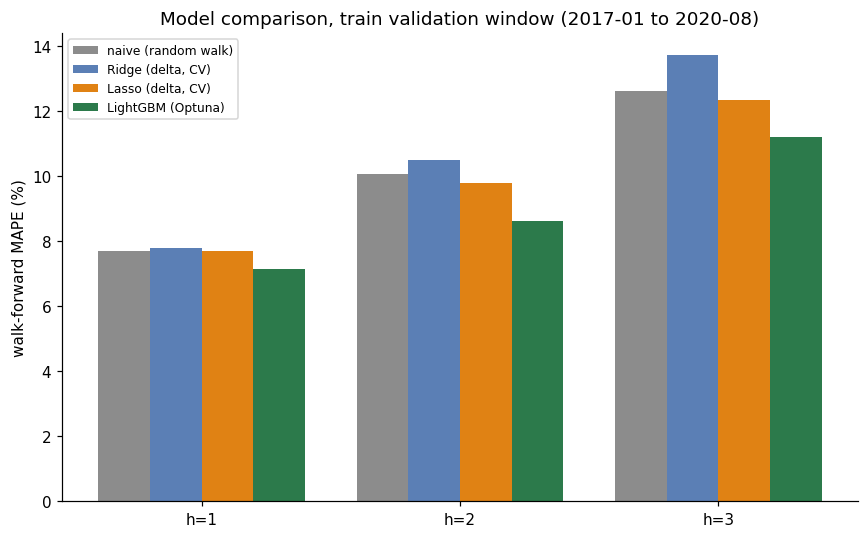

In [15]:
results_df = pd.DataFrame(results_records)
pivot = results_df.pivot(index="model", columns="horizon", values="mape")
pivot.columns = [f"h={h}" for h in pivot.columns]
model_order = ["naive (random walk)", "Ridge (delta, CV)", "Lasso (delta, CV)", "LightGBM (Optuna)"]
pivot = pivot.loc[model_order]
display(pivot.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(HORIZONS))
width = 0.2
colors = ["#8c8c8c", "#5b7fb5", "#e08214", "#2c7a4b"]
for i, model in enumerate(model_order):
    vals = [results_df.loc[(results_df["model"] == model) & (results_df["horizon"] == h), "mape"].iloc[0] for h in HORIZONS]
    ax.bar(x + (i - 1.5) * width, vals, width, label=model, color=colors[i])
ax.set_xticks(x)
ax.set_xticklabels([f"h={h}" for h in HORIZONS])
ax.set_ylabel("walk-forward MAPE (%)")
ax.set_title("Model comparison, train validation window (2017-01 to 2020-08)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**Step 3 takeaways**

- LightGBM beats the naive baseline at every horizon, and the gap widens with the horizon (h=1: 7.15% vs 7.71%; h=3: 11.20% vs 12.61%) — consistent with a random walk being closest to optimal one month out, and seasonality/storage information earning its keep further out.
- Lasso's built-in sparsity gets it to roughly naive-or-better at every horizon; Ridge, which can't zero out the weaker features, sits slightly behind naive at h=2/h=3. Between the two linear models, sparsity is doing real work here.
- LightGBM is the model carried into Step 4.

## Step 4 — Final backtest and submission

Same `walk_forward_predict` harness, pointed at the full history (train + test) with `test_df`'s 48 dates as the evaluation points. Because `walk_forward_predict` truncates to `history <= t` before anything else runs, this *is* the expanding-window retrain: at `t = 2020-09-30` the model sees only train; by `t = 2024-07-31` it has retrained on nearly four more years of actuals, one month at a time. Hyperparameters are the ones Optuna already chose in Step 3 against the train-only validation window — they are not re-tuned here, since doing so would mean selecting hyperparameters using the test period itself.

In [16]:
test_dates = test_df[DATE_COL].tolist()

final_preds_long = walk_forward_predict(full_history, make_model_predict_fn(lgbm_factory), test_dates, HORIZONS)

submission = final_preds_long.pivot(index=DATE_COL, columns="horizon", values="pred").reset_index()
submission.columns = [DATE_COL] + [f"pred_{h}" for h in HORIZONS]
submission = submission.sort_values(DATE_COL).reset_index(drop=True)
submission[DATE_COL] = submission[DATE_COL].dt.strftime("%Y-%m-%d")
for h in HORIZONS:
    submission[f"pred_{h}"] = submission[f"pred_{h}"].round(6)

submission_example = pd.read_csv(SUBMISSION_EXAMPLE_PATH)
assert list(submission.columns) == list(submission_example.columns), "column mismatch vs submission_example.csv"
assert list(submission[DATE_COL]) == list(submission_example[DATE_COL]), "date mismatch vs submission_example.csv"
assert len(submission) == 48, f"expected 48 rows, got {len(submission)}"
assert submission.isna().sum().sum() == 0, "submission contains NaNs"

submission.to_csv(SUBMISSION_OUT_PATH, index=False)
print(f"saved {SUBMISSION_OUT_PATH} -- {submission.shape[0]} rows, columns {list(submission.columns)}")
submission.head()

saved submission.csv -- 48 rows, columns ['date', 'pred_1', 'pred_2', 'pred_3']


,date,pred_1,pred_2,pred_3
0,2020-09-30,2.363697,2.538221,2.416720
1,2020-10-31,2.921933,2.991596,2.899766
2,2020-11-30,2.936164,2.896126,2.735811
3,2020-12-31,2.509474,2.351671,2.424285
4,2021-01-31,2.586142,2.462882,2.493492


### Honest accuracy check

`data_test.csv` has the real historical prices, so this isn't a guess: it's the actual walk-forward MAPE the submitted numbers would have scored, computed the same way as every earlier comparison (tail dates where the h+2/h+3 target falls past 2024-08-31 are dropped, not zero-filled).

In [17]:
full_truth = add_horizon_targets(full_history, TARGET, HORIZONS)
test_mape = score_walk_forward(final_preds_long, full_truth, HORIZONS)

naive_test_preds = walk_forward_predict(full_history, naive_predict, test_dates, HORIZONS)
naive_test_mape = score_walk_forward(naive_test_preds, full_truth, HORIZONS)

comparison = pd.DataFrame({
    "train validation MAPE (2017-2020)": lgbm_mape,
    "test backtest MAPE, naive (2020-2024)": naive_test_mape,
    "test backtest MAPE, LightGBM (2020-2024)": test_mape,
}).round(2)
comparison.index.name = "horizon"
display(comparison)

,train validation MAPE (2017-2020),"test backtest MAPE, naive (2020-2024)","test backtest MAPE, LightGBM (2020-2024)"
horizon,,,
1,7.15,13.65,13.63
2,8.63,22.92,20.63
3,11.20,29.18,27.03


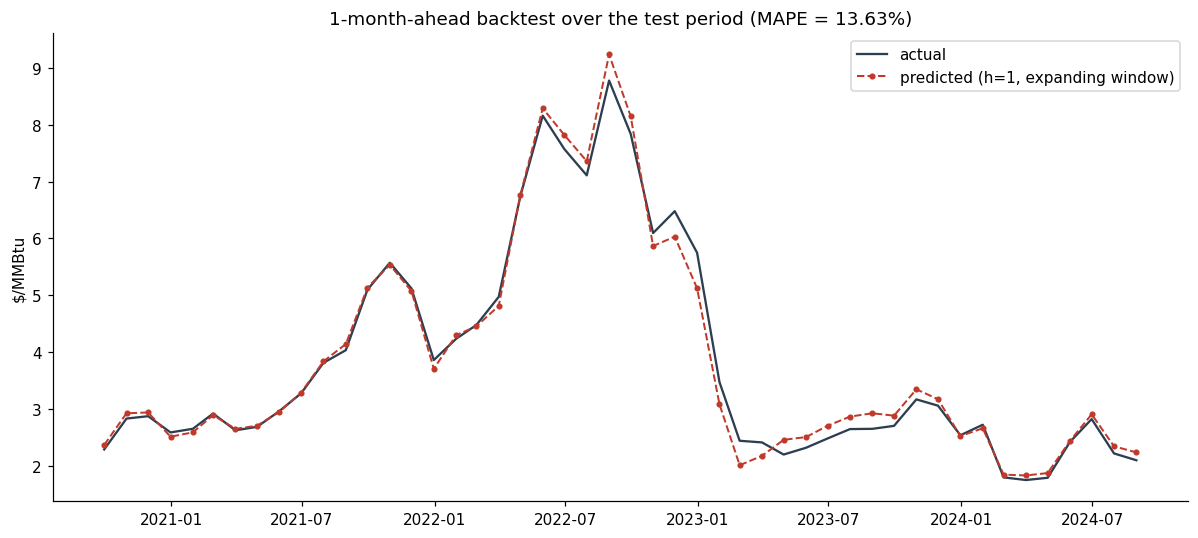

In [18]:
pred_h1 = final_preds_long.loc[final_preds_long["horizon"] == 1].sort_values(DATE_COL)

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test_df[DATE_COL], test_df[TARGET], color="#2c3e50", linewidth=1.5, label="actual")
ax.plot(pred_h1[DATE_COL], pred_h1["pred"], color="#c0392b", linewidth=1.3, linestyle="--",
        marker="o", markersize=3, label="predicted (h=1, expanding window)")
ax.set_ylabel("$/MMBtu")
ax.set_title(f"1-month-ahead backtest over the test period (MAPE = {test_mape[1]:.2f}%)")
ax.legend()
plt.tight_layout()
plt.show()

**Step 4 takeaways**

- `submission.csv` is written and validated against `submission_example.csv`'s header, dates, and row count (48, no NaNs).
- Test-period MAPE (13.6% / 20.6% / 27.0%) is roughly double the train-validation numbers, and that's expected rather than a bug: the test window contains the Texas freeze and the Ukraine-driven spike, a genuine regime shift with no precedent in 2017-2020. MAPE also mechanically inflates during the 2023-2024 low-price stretch (~$1.8-2), where even a small dollar miss is a large percentage.
- LightGBM still beats the naive baseline on the true test period at every horizon (13.63 vs 13.65, 20.63 vs 22.92, 27.03 vs 29.18) — a smaller edge than in the calmer validation window, but the ranking holds under the harder, honest evaluation.
- The backtest chart shows the model tracking the 2022 spike and the subsequent decline closely in shape and timing; the largest misses cluster right at the sharpest turns (the Aug-2022 peak, the Feb-2023 drop) — exactly where a model built on lagged momentum is structurally weakest, and exactly what Step 5 digs into.

## Step 5 — Feature attribution and inflection points

Two parts: global SHAP importance on a model fit to all available data (interpretation only — the submission itself never uses this model, it's Step 4's walk-forward refits), and then local explanations at specific dates around the 2021 and 2022 turning points, using the model exactly as it existed at that point in the walk-forward backtest.

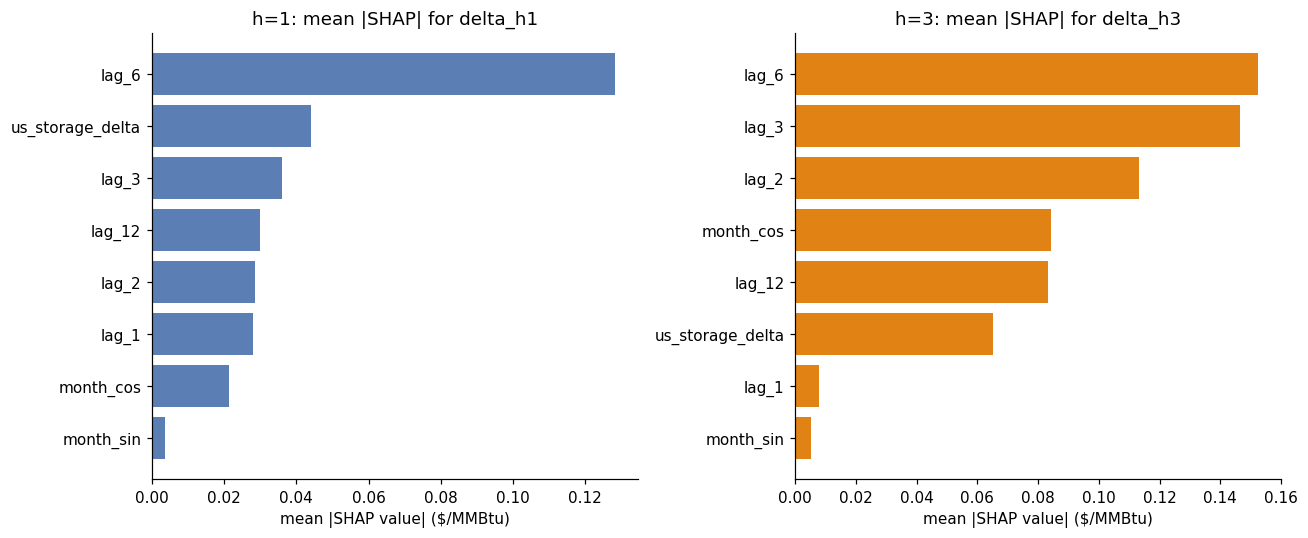

In [19]:
def fit_model_as_of(horizon: int, t: pd.Timestamp, panel: pd.DataFrame = full_history):
    """Refit the horizon-h LightGBM model on panel truncated to <= t, exactly like
    walk_forward_predict would. Returns (model, feature-row-at-t, training rows used)."""
    history = panel.loc[panel[DATE_COL] <= t]
    feats = build_features(history)
    feats[f"delta_h{horizon}"] = feats[TARGET].shift(-horizon) - feats[TARGET]
    train_rows = feats.dropna(subset=FEATURE_COLS + [f"delta_h{horizon}"])
    params = {**best_lgbm_params[horizon], **LGBM_FIXED_PARAMS}
    model = lgb.LGBMRegressor(**params)
    model.fit(train_rows[FEATURE_COLS], train_rows[f"delta_h{horizon}"])
    t_row = feats.loc[feats[DATE_COL] == t, FEATURE_COLS]
    return model, t_row, train_rows


# Global importance: one model per horizon fit on everything available, SHAP over its own
# training rows.
final_model_h1, _, rows_h1 = fit_model_as_of(1, full_history[DATE_COL].max())
final_model_h3, _, rows_h3 = fit_model_as_of(3, full_history[DATE_COL].max())

shap_h1 = shap.TreeExplainer(final_model_h1)(rows_h1[FEATURE_COLS])
shap_h3 = shap.TreeExplainer(final_model_h3)(rows_h3[FEATURE_COLS])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, shap_vals, title, color in [
    (axes[0], shap_h1, "h=1: mean |SHAP| for delta_h1", "#5b7fb5"),
    (axes[1], shap_h3, "h=3: mean |SHAP| for delta_h3", "#e08214"),
]:
    mean_abs = pd.Series(np.abs(shap_vals.values).mean(axis=0), index=FEATURE_COLS).sort_values()
    ax.barh(mean_abs.index, mean_abs.values, color=color)
    ax.set_title(title)
    ax.set_xlabel("mean |SHAP value| ($/MMBtu)")
plt.tight_layout()
plt.show()

Lag features dominate at both horizons, seasonality contributes least, and `us_storage_delta` earns a real (if secondary) place at both — consistent with Step 3's walk-forward results, where the feature set beat the naive baseline more clearly at longer horizons than at h=1. The specific lag that comes out on top (`lag_6`) shouldn't be over-read: the five lags are highly correlated with each other (the same collinearity that broke the raw-level Ridge fit earlier), so a tree-based model can lean on any one of them as a stand-in for "recent trend," and small differences in split gain decide which one wins. The robust signal is "lagged momentum matters, calendar seasonality barely does," not that six months specifically is a special number.

### Inflection points

Three snapshots, each using the h=1 model refit on exactly the data that would have been available at the time (`fit_model_as_of`, same function used for the global chart, just truncated earlier) — this is the actual model from the Step 4 backtest, not a hindsight refit.

Texas freeze: forecast made just before Feb 2021
  as of 2021-01-31: price = 2.649
  forecast for 2021-02-28 (h=1): 2.586
  actual 2021-02-28: 2.917
  error: -0.331  (-11.3%)


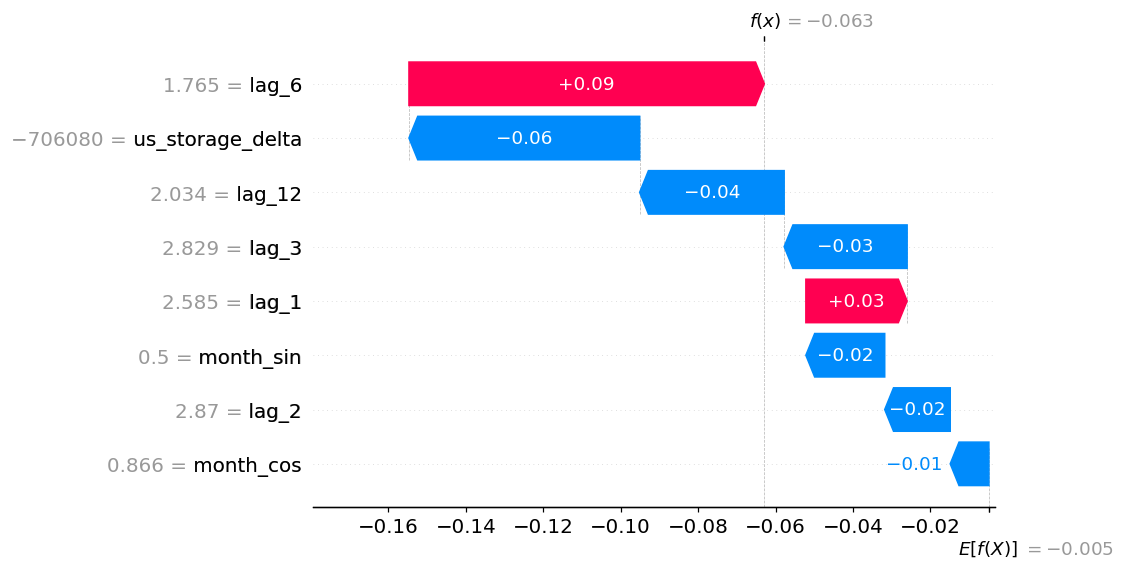

In [20]:
def explain_inflection(horizon: int, t: pd.Timestamp, label: str):
    model, t_row, _ = fit_model_as_of(horizon, t)
    predicted_delta = model.predict(t_row)[0]
    current_price = full_history.loc[full_history[DATE_COL] == t, TARGET].iloc[0]
    predicted_price = current_price + predicted_delta

    target_date_approx = t + pd.DateOffset(months=horizon)
    actual_row = full_history.loc[(full_history[DATE_COL] - target_date_approx).abs().idxmin()]
    actual_date, actual_price = actual_row[DATE_COL], actual_row[TARGET]

    print(label)
    print(f"  as of {t.date()}: price = {current_price:.3f}")
    print(f"  forecast for {actual_date.date()} (h={horizon}): {predicted_price:.3f}")
    print(f"  actual {actual_date.date()}: {actual_price:.3f}")
    print(f"  error: {predicted_price - actual_price:+.3f}  ({(predicted_price / actual_price - 1) * 100:+.1f}%)")

    shap_row = shap.TreeExplainer(model)(t_row)
    shap.plots.waterfall(shap_row[0], show=True)


explain_inflection(1, pd.Timestamp("2021-01-31"), "Texas freeze: forecast made just before Feb 2021")

The model predicted a *decline* (2.65 → 2.59) and price actually jumped to 2.92, an 11.3% miss in the wrong direction. The waterfall shows why: the second-biggest push was a large negative `us_storage_delta` (-706,080 MMcf, a big January withdrawal), which the model reads as a bearish signal — historically, a big seasonal winter draw is often followed by prices easing into February as peak heating risk passes. That pattern is real and usually correct; it just isn't what happened this time. Winter Storm Uri (Feb 10-20, 2021) froze wellheads and processing equipment across Texas, cutting a large share of *production* at the same moment heating demand spiked — a simultaneous supply-and-demand shock over about a week. Nothing in an 8-feature, monthly-granularity model can see that coming: there's no daily temperature-extreme signal and no infrastructure-outage proxy, only a contemporaneous monthly average that doesn't yet reflect a storm that hadn't happened when the forecast was made.

Ukraine invasion: forecast made just before Feb 2022
  as of 2022-01-31: price = 4.233
  forecast for 2022-02-28 (h=1): 4.297
  actual 2022-02-28: 4.475
  error: -0.178  (-4.0%)


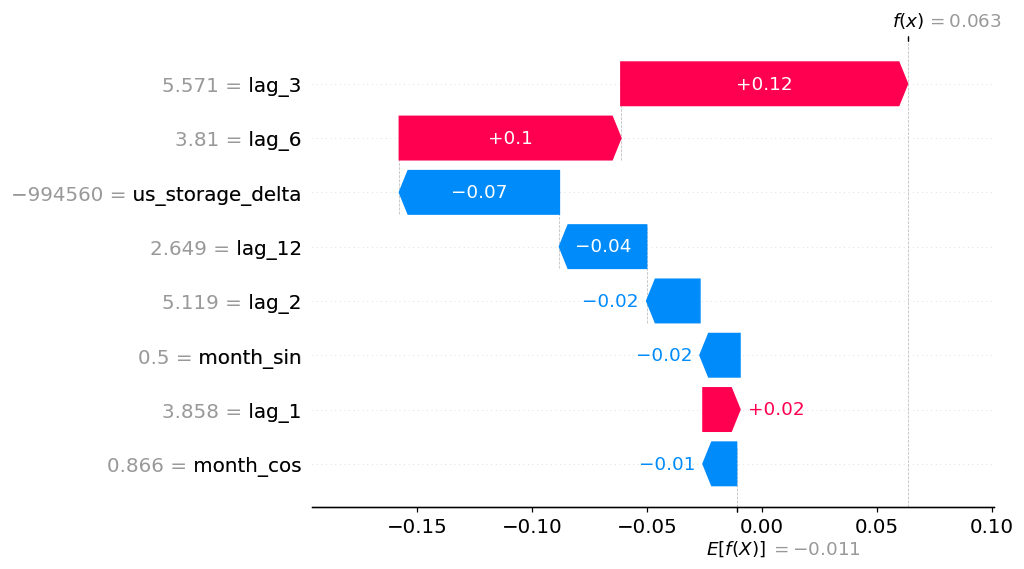

In [21]:
explain_inflection(1, pd.Timestamp("2022-01-31"), "Ukraine invasion: forecast made just before Feb 2022")

A smaller miss (-4.0%) than the Texas freeze, and for a related reason: Russia's invasion (Feb 24) landed three-quarters of the way through the forecasted month, and Henry Hub's initial reaction was muted compared to European gas (TTF), which gapped up immediately. The US price move was never really about a direct physical link to Russian supply — the US doesn't import Russian gas — it came later and indirectly, through LNG. As European buyers paid up for any non-Russian LNG cargo they could get, US export terminals had every incentive to route more gas overseas, tightening the domestic balance and pulling Henry Hub up with a lag. The next snapshot, several months into that process, is where the model's momentum features should have more to work with.

Mid-crisis: forecast made just before Jun 2022, four months into the LNG-driven runup
  as of 2022-05-31: price = 8.160
  forecast for 2022-06-30 (h=1): 8.289
  actual 2022-06-30: 7.571
  error: +0.718  (+9.5%)


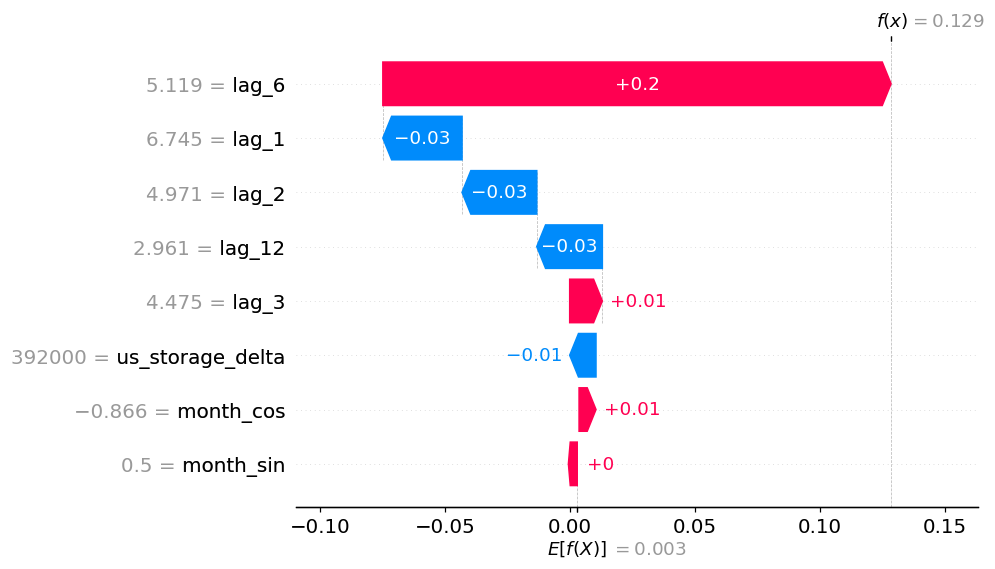

In [22]:
explain_inflection(1, pd.Timestamp("2022-05-31"), "Mid-crisis: forecast made just before Jun 2022, four months into the LNG-driven runup")

This one overshoots (+9.5%) in the opposite way: the model extrapolates the rally it has been riding for months — `lag_6` (the November 2021 price, still well below where the market had climbed to) contributes +0.20 to the predicted delta, the single largest push seen in any of these three snapshots — and predicts June keeps climbing to 8.29. Actual June 2022 fell to 7.57. The reason is a discrete event a pure momentum signal has no way to anticipate: an explosion and fire at the Freeport LNG export terminal on June 8, 2022 took roughly a fifth of US LNG export capacity offline for months. Less gas being pulled toward export terminals means more staying in the domestic market — the same LNG-export channel that had been pushing Henry Hub *up* all spring flipped and pushed it back *down*, and the model, still reading recent lags as "the rally continues," missed the reversal.

Read together, the three snapshots make one point three ways: this feature set is good at extrapolating a trend that's already underway and structurally blind to the discrete supply/demand shocks — a storm, an invasion, a terminal fire — that start or end one. That's a property of the *feature set*, not something a better hyperparameter search would fix; capturing it would need genuinely different inputs (e.g. a forward weather signal, LNG terminal utilization, a supply-disruption flag), which is where real forecasting effort should go next.

## Summary

- Naive random walk is a hard baseline (7.7% / 10.1% / 12.6% MAPE at h=1/2/3 on the 2017-2020 validation window); a first pass at Ridge/Lasso on raw price levels actually lost to it because of lag collinearity, fixed by reframing every model to predict the *change* in price instead.
- LightGBM, tuned with Optuna against that same validation window, beat the naive baseline at every horizon there and, more importantly, still beat it on the true out-of-sample test backtest (13.6% / 20.6% / 27.0% vs 13.7% / 22.9% / 29.2%), even though that period contains two regime shifts the training data never saw.
- `submission.csv` is the expanding-window backtest output, validated against `submission_example.csv`'s format.
- SHAP attribution and three inflection-point snapshots point to the same conclusion: the model works by extrapolating recent momentum plus a storage-delta signal, which is a reasonable strategy in normal conditions and a structurally blind one at the exact moments — a freeze, an invasion, a terminal fire — that matter most for "did you predict the turning point." That's the honest limitation of an 8-feature, monthly-granularity model on 204 training rows, and the clearest direction for further work.